# Decision Trees, Random Forests and Ensemble Methods

The purpose of this practical work is to implement differents methods based on Decision Trees. We will also focus on using a good protocol to evaluate our model.

First, we will ensure that your configuration is ok. Run the following code to check if everything is running well

In [6]:
%load_ext autoreload
%autoreload 2

#check du kernel name de ipykernel
import ipykernel
info= dict(eval(ipykernel.get_connection_info().replace("=",":")))
print(info["kernel_name"])
# devrait afficher ia_pour_la_chimie


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
ia_pour_la_chimie


In [7]:
%matplotlib inline 

# pour afficher les graphiques dans le notebook

# Utility libraries
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

import matplotlib.pyplot as plt


## Simple Decision Tree 

First, let's download a toy dataset to learn a decision tree, the iris dataset. Check the documentation to understand what it represent.

1) using the default values provided by sklearn, learn a simple decision tree.
2) explain the displayed figure.

In [9]:
%matplotlib inline 
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


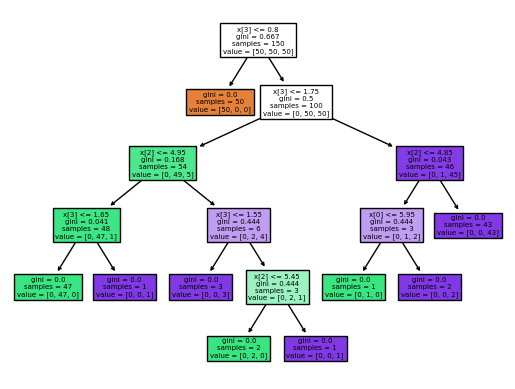

In [11]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

iris = load_iris()
clf = DecisionTreeClassifier()
clf = clf.fit(iris.data, iris.target)
tree.plot_tree(clf,label='all',filled=True,impurity=True);


 3) Change the max depth to 3. What do you expect ?

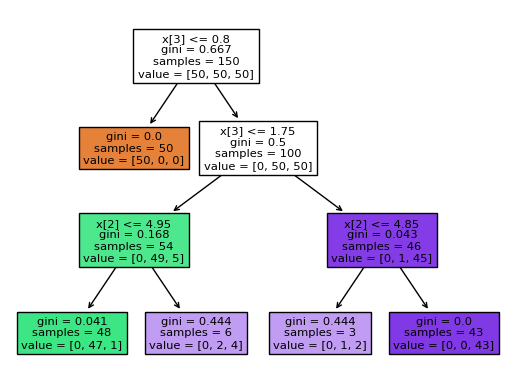

In [12]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
clf = DecisionTreeClassifier(max_depth=3)
clf = clf.fit(iris.data, iris.target)
tree.plot_tree(clf,label='all',filled=True,impurity=True);


Now, we know how to learn a classifier, we will focus on the design  of a predictive model, by setting its hyperparameters in a proper way.

1) Identify the hyperparameters to tune
2) Identify a protocol to fit correctly the hyperparameters
3) How do you measure the final performance of your model ?
4) Implement the code to find an optimal value for each hyperparameter


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=30,random_state=10)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=30, random_state=10)

#parameters 
max_depth =  np.arange(1,10)
print(max_depth)
perfs_train = []
perfs_val = []
perfs_test = []
for i in max_depth:
    clf = DecisionTreeClassifier(max_depth=i)
    clf.fit(X_train,y_train)
    perf_train = accuracy_score(y_train, clf.predict(X_train))
    perf_val = accuracy_score(y_val, clf.predict(X_val))
    perf_test = accuracy_score(y_test, clf.predict(X_test))

    print(f" {i = } : {perf_train =:.2f}, {perf_val =:.2f}")
    perfs_train.append(perf_train)
    perfs_val.append(perf_val)
    perfs_test.append(perf_test)

optimal_max_depth = max_depth[np.argmax(perfs_val)]
print(optimal_max_depth)
clf = DecisionTreeClassifier(max_depth=optimal_max_depth)
clf.fit(X_train,y_train)
print(f"score final : {accuracy_score(y_test,clf.predict(X_test)):.2f}")

[1 2 3 4 5 6 7 8 9]
 i = 1 : perf_train =0.71, perf_val =0.63
 i = 2 : perf_train =0.97, perf_val =0.93
 i = 3 : perf_train =0.97, perf_val =0.90
 i = 4 : perf_train =1.00, perf_val =0.90
 i = 5 : perf_train =1.00, perf_val =0.90
 i = 6 : perf_train =1.00, perf_val =0.90
 i = 7 : perf_train =1.00, perf_val =0.90
 i = 8 : perf_train =1.00, perf_val =0.90
 i = 9 : perf_train =1.00, perf_val =0.90
2
score final : 0.93


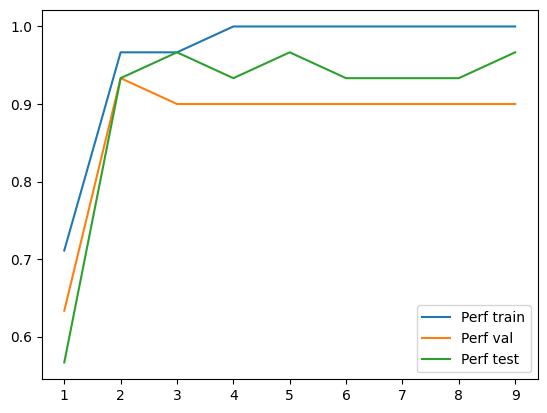

In [23]:
plt.plot(max_depth, perfs_train, label="Perf train")
plt.plot(max_depth, perfs_val, label="Perf val")
plt.plot(max_depth, perfs_test, label="Perf test")
plt.legend()

To make your life easier, sklearn developpers develop the `GridSearchCV` class which mimics your previous code, but in a more efficient way

1) Adapt your code to run the `GridSearchCV` and find the best hyperparameters
2) What does `GridSearchCV` do ?
3) Retrieve the validation accuracy of your `GridSearchCV`

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=0)
parameters = {'max_depth':np.arange(1,10)}

clf = tree.DecisionTreeClassifier()
cv = GridSearchCV(clf, parameters,verbose=2,cv=10)
cv.fit(X_train, y_train)
#cv.cv_results_
print(f"{cv.best_params_=}")
#print(f"{cv.best_score_=}, {cv.score.__name__ =}")
y_pred = cv.predict(X_test)
print(f"score final : {accuracy_score(y_test,y_pred):.2f}")

Fitting 10 folds for each of 9 candidates, totalling 90 fits
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=1; total time=   0.0s
[CV] END ........................................max_depth=2; total time=   0.0s
[CV] END .......................................

## Random Forests

Now, we will enchance our model by implementing a Random Forest. To this end, let's use the `RandomForestClassifier` class of scikit-learn.

1) Why not using `RandomForestRegressor` ?
2) Retrieve the hyperparameter discussed in class in this implementation
3) How is made the final decision ?
4) Learn a simple RandomForest and give the performance on test set
5) Define the hyperparameters values to be tuned
6) Learn your model, and conclude. 


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
perf_test = []
for _ in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.1)
    parameters = {"n_estimators":[5,10,20,50,100],"max_depth":[None], "max_features":["sqrt"],"min_samples_split":[2]}
    clf = RandomForestClassifier()
    cv = GridSearchCV(clf,parameters)
    cv.fit(X_train,y_train)
    print(f"{cv.best_params_=}")
    print(f"{cv.best_score_=:.2f}")
    perf_test.append(accuracy_score(y_test,cv.predict(X_test)))

print(f"score final : {np.mean(perf_test):.2f} +- {np.std(perf_test):.2f}")




cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 5}
cv.best_score_=0.95
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 5}
cv.best_score_=0.95
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 5}
cv.best_score_=0.94
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
cv.best_score_=0.96
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
cv.best_score_=0.96
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 10}
cv.best_score_=0.94
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
cv.best_score_=0.96
cv.best_params_={'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 10}
cv.best_score_=0.93
cv.best_par

### Increasing the difficulty

Now, we will focus on a chemical dataset, used in one of our research papers.

This dataset is devoted to predict Mayr's experimental scale for electrophilicity. All electrophiles available in Mayr's Database (319 electrophiles) have been selected and then subjected to successive selections to finally obtain a database made of 111 molecules. Here the graph are described by 19 descriptors and each atom by 50 descriptors, including quantum chemical descriptors. To have more details on the chemical side, see with Vincent Tognetti.

> Hoffmann, Guillaume, Muhammet Balcilar, Vincent Tognetti, Pierre Héroux, Benoit Benoît Gaüzère, Sébastien Adam, et Laurent Joubert. 2020. « Predicting experimental electrophilicities from quantum and topological descriptors: A machine learning approach ». Journal of Computational Chemistry 41 (24): 2124‑36. https://doi.org/10.1002/jcc.26376.



In [40]:
from datasets.cobra import CobraDataset

data_Cobra = CobraDataset()
X_cobra_graph = data_Cobra.graph_data
X_cobra_atom = data_Cobra.atom_data
X_cobra_graph_atom = data_Cobra.all_data
y_cobra = data_Cobra.targets



In [44]:
y_cobra

array([ -9.42, -10.8 ,  13.3 , -13.56, -11.32, -10.11, -14.68, -10.37,
       -12.76, -13.84, -10.73, -11.89, -10.28, -12.76, -13.97, -20.55,
       -17.67, -18.06, -18.98, -21.11, -21.47, -11.87, -16.38, -17.18,
       -16.36, -15.03, -14.5 , -14.36, -14.7 , -14.23, -13.85, -13.37,
       -12.61, -12.37, -11.52,  -8.63, -12.18, -13.39, -15.83, -16.11,
       -17.29, -17.9 ,   7.96,   7.52,   6.87,   6.74,   6.7 ,   6.23,
         6.11,   5.48,   5.47,   5.24,   5.2 ,   4.43,   4.15,   3.63,
         2.9 ,   2.85,   2.7 ,   2.11,   1.48,   1.23,   0.61,   0.  ,
        -0.81,  -1.36,  -1.45,  -1.8 ,  -2.19,  -3.02,  -3.14,  -3.85,
        -4.72,  -4.96,  -5.05,  -5.15,  -5.53,  -5.89,  -5.9 ,  -5.9 ,
        -5.99,  -6.  ,  -6.  ,  -6.1 ,  -6.26,  -6.9 ,  -7.2 ,  -7.02,
        -7.  ,  -7.3 ,  -7.5 ,  -7.69,  -7.79,  -8.  ,  -8.2 ,  -8.22,
        -8.5 ,  -8.6 ,  -8.76,  -5.15,  -9.45,  -9.78,  -9.8 , -10.04,
       -10.23, -10.6 , -13.19,  -9.05,  -4.67,  -5.46, -12.33])

1. What kind of problem is it ? (Check the values of y)
2. Using a proper protol, compare the predictive power of the 3 set of descriptors
3. Which one is the best ? What is your confidence ?

In [45]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
import numpy as np


In [50]:
methods = [
    {"name": "Global inputs", "X": X_cobra_graph},
    {"name": "Atom inputs", "X": X_cobra_atom},
    {"name": "Combined inputs",  "X": X_cobra_graph_atom}
]

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm 
perf_test = []

for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split(X_cobra_graph,y_cobra,test_size=0.1)
    parameters = {"n_estimators":[5,10,20,50,100],"max_depth":[None], "max_features":[None],"min_samples_split":[2]}
    reg = RandomForestRegressor()
    cv = GridSearchCV(reg,parameters)
    cv.fit(X_train,y_train)
    perf_test.append(mean_absolute_error(y_test,cv.predict(X_test)))

print(f"score final : {np.mean(perf_test):.2f} +- {np.std(perf_test):.2f}")

for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split(X_cobra_atom,y_cobra,test_size=0.1)
    parameters = {"n_estimators":[5,10,20,50,100],"max_depth":[None], "max_features":[None],"min_samples_split":[2]}
    reg = RandomForestRegressor()
    cv = GridSearchCV(reg,parameters)
    cv.fit(X_train,y_train)
    perf_test.append(mean_absolute_error(y_test,cv.predict(X_test)))

print(f"score final : {np.mean(perf_test):.2f} +- {np.std(perf_test):.2f}")

for _ in tqdm(range(10)):
    X_train, X_test, y_train, y_test = train_test_split(X_cobra_graph_atom,y_cobra,test_size=0.1)
    parameters = {"n_estimators":[5,10,20,50,100],"max_depth":[None], "max_features":[None],"min_samples_split":[2]}
    reg = RandomForestRegressor()
    cv = GridSearchCV(reg,parameters)
    cv.fit(X_train,y_train)
    perf_test.append(mean_absolute_error(y_test,cv.predict(X_test)))

print(f"score final : {np.mean(perf_test):.2f} +- {np.std(perf_test):.2f}")



100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:07<00:00,  1.40it/s]


score final : 2.28 +- 1.12


100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:38<00:00,  3.85s/it]


score final : 2.02 +- 0.99


100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:41<00:00,  4.16s/it]

score final : 1.84 +- 0.92


In [ ]:
from sklearn.ensemble import ...

parameters = {...}
regressor = ...

maes = {m['name']:[] for m in methods}
...
#Résultats
for m in methods:
    print(f"{m['name']}: Mean MAE = {np.mean(maes[m['name']]):.2f}, Std MAE = {np.std(maes[m['name']]):.2f}")
               

## Ensemble methods with Boosting

Random forest are just one kind of ensemble methods based on trees. Others methods, more complex, have been proposed. Here, we will test two famous one : Gradient Boosting Decision Trees and Xgboost. These methods are the state of the art when dealing with tabular data.

1) Implement a simple `GradientBoostingRegressor` from the scikit-learn library
2) As usual, what hyperparameters will you focus on ? Do you understand them ?
3) Find the best hyperparameters and compute the performance on test set.
4) Do the same using the `XGBRegressor` from xgboost library. Comment on similar things.

In [ ]:
import xgboost as xgb

## 
## Same thing with Xgboost !
maes = {m['name']:[] for m in methods}
parameters = { ...}
regressor = ...

# A completer 
for m in methods:
    print(f"{m['name']}: Mean MAE = {np.mean(maes[m['name']]):.2f}, Std MAE = {np.std(maes[m['name']]):.2f}")
               
